In [ ]:
# XGBoost y SHAP normalmente ya vienen en Colab, pero forzamos versión reciente
!pip install -q xgboost shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
import shap

# Semilla para que los resultados sean reproducibles
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# Carga de rutas locales (reemplaza montado de Google Drive)
ruta_ventas = 'datasets/ventas.csv'
ruta_detalle = 'datasets/detalle-ventas.csv'
print("Rutas configuradas:")
print("Ventas:", ruta_ventas)
print("Detalle:", ruta_detalle)


Mounted at /content/drive
ventas.csv encontrado en: ['/content/drive/MyDrive/dataset/ventas.csv']
detalle-ventas.csv encontrado en: ['/content/drive/MyDrive/dataset/detalle-ventas.csv']


### Carga de datos

In [5]:
def cargar_ventas(path):
    """Carga el archivo de cabecera de ventas (una fila por venta)."""
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    # format='mixed' deja que pandas detecte el formato de cada fecha individualmente
    # (soluciona el caso donde hay fechas con y sin hora, o en distinto orden)
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed', errors='coerce')
    return df

def cargar_detalle_ventas(path):
    """Carga el detalle de productos por venta (varias filas por venta).
    Nota: la primera fila del CSV es basura (';;;;...') por eso usamos skiprows=1,
    y luego eliminamos columnas 'Unnamed' que sobran al final."""
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig', skiprows=1)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed', errors='coerce')
    return df

ventas = cargar_ventas(ruta_ventas)
detalle = cargar_detalle_ventas(ruta_detalle)

# Diagnóstico: revisa si alguna fecha no se pudo interpretar (saldría como NaT)
print("Fechas no reconocidas en ventas:", ventas['Fecha'].isna().sum())
print("Fechas no reconocidas en detalle:", detalle['Fecha'].isna().sum())

print("Ventas:", ventas.shape)
print("Detalle de ventas:", detalle.shape)
ventas.head()

Fechas no reconocidas en ventas: 0
Fechas no reconocidas en detalle: 0
Ventas: (854, 5)
Detalle de ventas: (1145, 9)


,ID,Fecha,Metodo_Pago,ID_Cliente,Total
0,VTA-0000001,2026-03-15,YAPE,1,9.4
1,VTA-0000002,2026-03-15,EFECTIVO,1,1.2
2,VTA-0000003,2026-03-15,EFECTIVO,1,10.0
3,VTA-0000004,2026-03-15,EFECTIVO,1,19.6
4,VTA-0000005,2026-03-16,YAPE,1,1.8


### Ingeniería de características

In [6]:
def construir_features_detalle(detalle):
    """Resume la información de productos de detalle-ventas.csv a una fila por venta."""
    agg = detalle.groupby('ID_Venta').agg(
        hora_compra=('Fecha', lambda x: x.dt.hour.iloc[0]),
        n_items=('Cantidad', 'sum'),
        n_productos_distintos=('ID_Producto', 'nunique'),
        departamento_principal=('Departamento', lambda x: x.mode().iloc[0]),
        pct_fotocopiadora=('Departamento', lambda x: (x == 'FOTOCOPIADORA').mean())
        # OJO: 'Medio' se descarta a propósito: es idéntico a Metodo_Pago (fuga de datos)
    ).reset_index()
    return agg

def construir_dataset_modelo(ventas, detalle):
    """Une ventas.csv (Metodo_Pago, Total, Fecha) con el resumen de detalle-ventas.csv."""
    feats_detalle = construir_features_detalle(detalle)

    df = ventas.merge(feats_detalle, left_on='ID', right_on='ID_Venta', how='inner')

    df['dia_semana'] = df['Fecha'].dt.dayofweek  # 0=Lunes ... 6=Domingo
    df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # Variable objetivo: 1 = YAPE, 0 = EFECTIVO
    df['target'] = df['Metodo_Pago'].map({'YAPE': 1, 'EFECTIVO': 0})

    columnas_finales = [
        'ID', 'Total', 'hora_compra', 'n_items', 'n_productos_distintos',
        'departamento_principal', 'pct_fotocopiadora', 'dia_semana',
        'es_fin_de_semana', 'target'
    ]
    return df[columnas_finales]

dataset = construir_dataset_modelo(ventas, detalle)
print(dataset.shape)
print(dataset['target'].value_counts(normalize=True))  # revisar balance de clases
dataset.head()

(854, 10)
target
0    0.662763
1    0.337237
Name: proportion, dtype: float64


,ID,Total,hora_compra,n_items,n_productos_distintos,departamento_principal,pct_fotocopiadora,dia_semana,es_fin_de_semana,target
0,VTA-0000001,9.4,0,5,2,FOTOCOPIADORA,0.5,6,1,1
1,VTA-0000002,1.2,0,1,0,UTILES,0.0,6,1,0
2,VTA-0000003,10.0,0,17,2,FOTOCOPIADORA,1.0,6,1,0
3,VTA-0000004,19.6,0,245,1,FOTOCOPIADORA,1.0,6,1,0
4,VTA-0000005,1.8,0,3,1,UTILES,0.0,0,0,1


### Análisis Exploratorio de Variables Predictoras

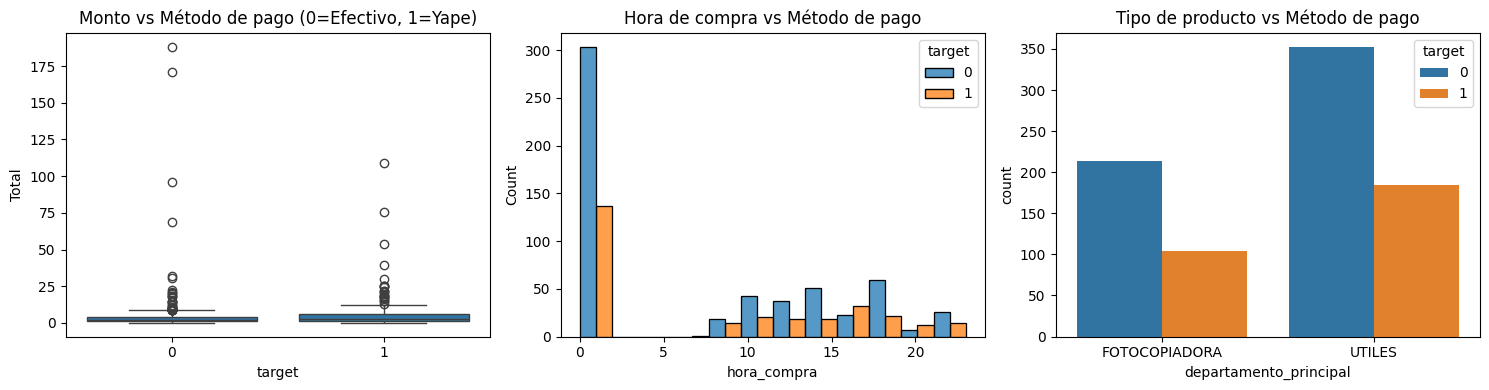

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=dataset, x='target', y='Total', ax=axes[0])
axes[0].set_title('Monto vs Método de pago (0=Efectivo, 1=Yape)')

sns.histplot(data=dataset, x='hora_compra', hue='target', multiple='dodge', ax=axes[1], bins=12)
axes[1].set_title('Hora de compra vs Método de pago')

sns.countplot(data=dataset, x='departamento_principal', hue='target', ax=axes[2])
axes[2].set_title('Tipo de producto vs Método de pago')

plt.tight_layout()
plt.show()

### Codificación y Train/Test Split

In [8]:
def preparar_datos(dataset, test_size=0.2):
    """Codifica variables categóricas y separa en train/test."""
    df = dataset.copy()

    le_depto = LabelEncoder()
    df['departamento_principal_enc'] = le_depto.fit_transform(df['departamento_principal'])

    X = df[['Total', 'hora_compra', 'n_items', 'n_productos_distintos',
            'departamento_principal_enc', 'pct_fotocopiadora',
            'dia_semana', 'es_fin_de_semana']]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    return X_train, X_test, y_train, y_test, le_depto

X_train, X_test, y_train, y_test, le_depto = preparar_datos(dataset)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (683, 8)  Test: (171, 8)


### Entrenamiento y Evaluación

In [9]:
def entrenar_y_evaluar(modelo, nombre, X_train, y_train, X_test, y_test):
    """Entrena un modelo, calcula métricas y grafica su matriz de confusión."""
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=['EFECTIVO', 'YAPE']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['EFECTIVO', 'YAPE'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

    return modelo, metricas

### Modelo 1 aplicado: Random Forest


--- Random Forest ---
              precision    recall  f1-score   support

    EFECTIVO       0.70      0.78      0.74       113
        YAPE       0.44      0.34      0.39        58

    accuracy                           0.63       171
   macro avg       0.57      0.56      0.56       171
weighted avg       0.61      0.63      0.62       171



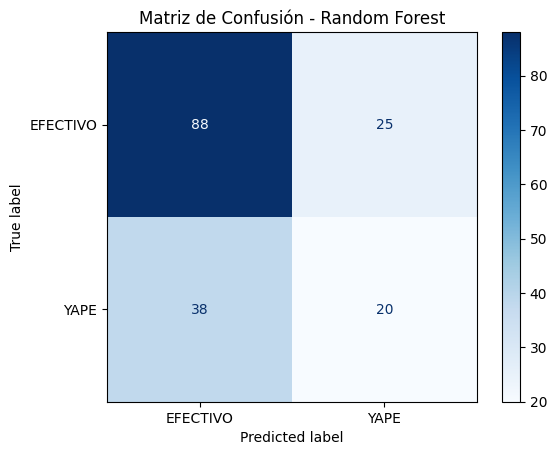

In [10]:
rf_modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',   # compensa el desbalance (66% Efectivo / 34% Yape)
    random_state=RANDOM_STATE
)

rf_modelo, rf_metricas = entrenar_y_evaluar(
    rf_modelo, "Random Forest", X_train, y_train, X_test, y_test
)

### Modelo 2 aplicado: XG Boost


--- XGBoost ---
              precision    recall  f1-score   support

    EFECTIVO       0.67      0.58      0.62       113
        YAPE       0.35      0.43      0.38        58

    accuracy                           0.53       171
   macro avg       0.51      0.51      0.50       171
weighted avg       0.56      0.53      0.54       171



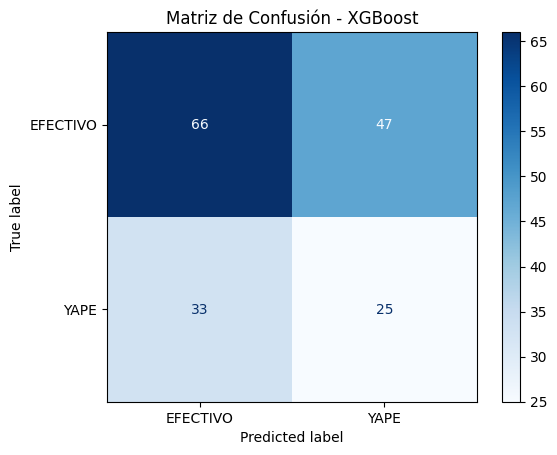

In [11]:
# scale_pos_weight compensa el desbalance de clases en XGBoost
peso_balance = (y_train == 0).sum() / (y_train == 1).sum()

xgb_modelo = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=peso_balance,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_modelo, xgb_metricas = entrenar_y_evaluar(
    xgb_modelo, "XGBoost", X_train, y_train, X_test, y_test
)

### Comparación de ambos modelos

               accuracy  precision  recall     f1  roc_auc
modelo                                                    
Random Forest     0.632      0.444   0.345  0.388    0.581
XGBoost           0.532      0.347   0.431  0.385    0.514


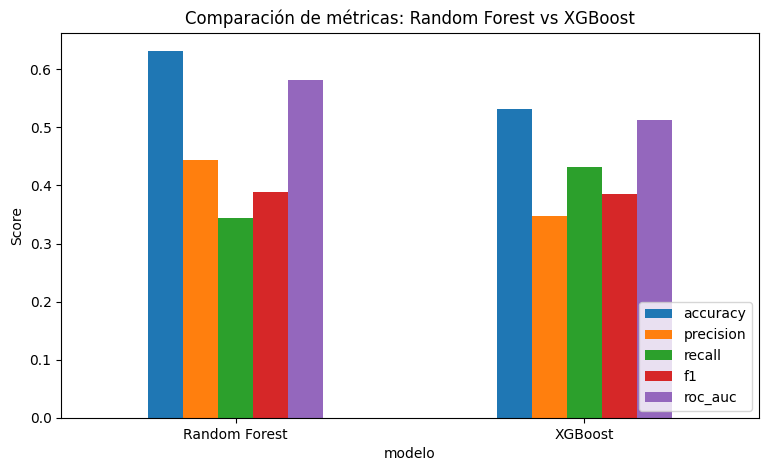

In [12]:
comparacion = pd.DataFrame([rf_metricas, xgb_metricas]).set_index('modelo')
print(comparacion.round(3))

comparacion.plot(kind='bar', figsize=(9, 5))
plt.title('Comparación de métricas: Random Forest vs XGBoost')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

### Interpretabilidad con SHAP

Modelo elegido para SHAP: Random Forest


/tmp/ipykernel_1209/2119436761.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_clase1, X_test, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


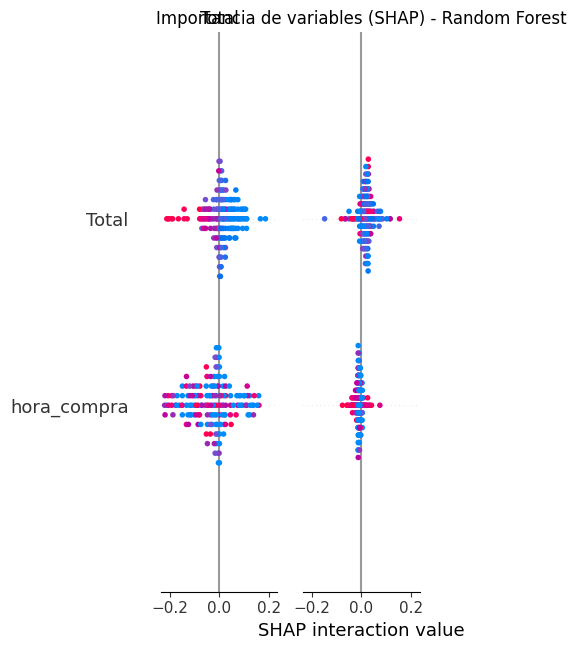

/tmp/ipykernel_1209/2119436761.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_clase1, X_test, show=False)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


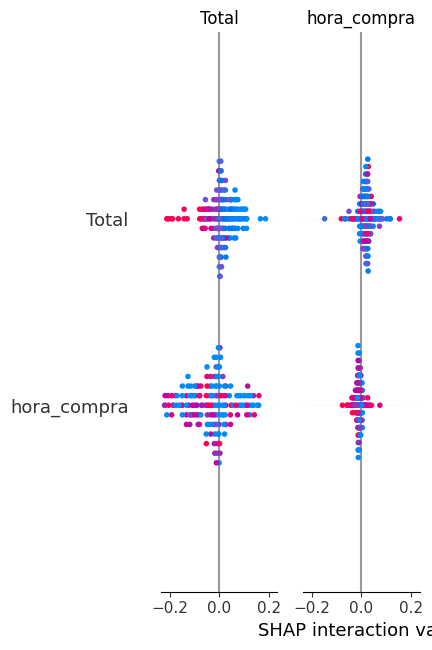

In [13]:
mejor_modelo, nombre_mejor = (
    (xgb_modelo, "XGBoost") if xgb_metricas['f1'] >= rf_metricas['f1']
    else (rf_modelo, "Random Forest")
)
print(f"Modelo elegido para SHAP: {nombre_mejor}")

explainer = shap.TreeExplainer(mejor_modelo)
shap_values = explainer.shap_values(X_test)

# Random Forest devuelve una lista [clase0, clase1]; XGBoost devuelve un solo array
valores_shap_clase1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# Gráfico resumen: qué variables más influyen en predecir YAPE
shap.summary_plot(valores_shap_clase1, X_test, plot_type="bar", show=False)
plt.title(f'Importancia de variables (SHAP) - {nombre_mejor}')
plt.tight_layout()
plt.show()

# Gráfico de dispersión: cómo influye cada variable (dirección + magnitud)
shap.summary_plot(valores_shap_clase1, X_test, show=False)
plt.tight_layout()
plt.show()

### Guardado del modelo

In [14]:
import os
import pickle

ruta_guardado = "models/modelo_metodo_pago.pkl"
os.makedirs("models", exist_ok=True)

with open(ruta_guardado, 'wb') as f:
    pickle.dump({
        'modelo': mejor_modelo,
        'label_encoder_departamento': le_depto,
        'columnas': list(X_train.columns)
    }, f)

print("Modelo guardado exitosamente en:", ruta_guardado)


Modelo guardado en: /content/drive/MyDrive/dataset/modelo_metodo_pago.pkl
